# Analisis NLP de Reviews

En este notebook analizamos las reseñas de una empresa concreta y las comparamos con las de su competencia dentro del mismo sector.

Objetivos del proyecto:
- cargar y entender los datos
- aislar la empresa objetivo y su competencia
- limpiar el texto para poder analizarlo
- detectar temas principales con embeddings y clustering
- medir el sentimiento de las reseñas
- comparar resultados para extraer conclusiones


## 1. Carga de librerias y datos

Primero importamos las librerias necesarias y cargamos el dataset completo de Trustpilot.
La idea en este punto es entender qué columnas tenemos disponibles antes de filtrar la empresa a estudiar.


In [59]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import pipeline
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from bertopic import BERTopic

# Cargamos el dataset general con todas las reviews.
df = pd.read_csv("./data/trustpilot-reviews-123k.csv")

# Mostramos las primeras filas para inspeccionar la estructura.
df.head()


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5
3,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Brilliant coats,Brilliant coats. Really like the limited editi...,5
4,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great company and products,Great company and products. This is my 3rd dry...,5


## 2. Seleccion de la empresa objetivo

Aqu? definimos la empresa que queremos analizar y creamos un subconjunto solo con sus rese?as.
Esto nos permite centrar el estudio en un caso concreto antes de compararlo con el resto del mercado.


In [60]:
# Elegimos la empresa principal del analisis.
nombre_empresa = "www.sonicdirect.co.uk"

# Filtramos un dataframe solo con las reviews de esa empresa.
df_empresa = df[df["company"] == nombre_empresa].copy()

print(f"Dimensiones del dataset: {df_empresa.shape}")
df_empresa.head()


Dimensiones del dataset: (100, 6)


,category,company,description,title,review,stars
32160,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Really impressed,"Really impressed, ordered on 27th Dec,wasn't e...",5
32161,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,"Great price, fantastic delivery",We purchased a tumble drier over the Christmas...,5
32162,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Very efficient,"Easy to order, very quick delivery time even o...",5
32163,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Our washing machine,Our washing machine broke down two days befor...,5
32164,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,"Well informed sales person, resulted in our pu...","The sales person was well informed, however, a...",5


In [61]:
# Identificamos el sector de la empresa para poder compararla con competidores similares.
sector = df_empresa["category"].iloc[0]
print(sector)


Electronics & Technology


## 3. Construccion del grupo de competencia

Una vez conocido el sector, extraemos todas las reviews de otras empresas de la misma categor?a.
As? conseguimos una referencia realista para comparar sentimiento, temas y valoraciones.


In [62]:
# Seleccionamos empresas del mismo sector, excluyendo la empresa objetivo.
df_competencia = df[
    (df["category"] == sector) &
    (df["company"] != nombre_empresa)
].copy()

print(f"Dimensiones del dataset de la competencia: {df_competencia.shape}")
df_competencia.head()


Dimensiones del dataset de la competencia: (5496, 6)


,category,company,description,title,review,stars
29662,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Dave 55,Excellent service as always shout out to Jerom...,5
29663,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Great service from Richer Sounds…,Great service from the Richer Sounds team at S...,5
29664,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Wanted a TV for an 84 year old relative…,Wanted a TV for an 84 year old relative who’s ...,5
29665,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,IMFORMED FRIENDLY HELP FROM RICHER SOUNDS,Excellent rapport and helpfulness with your So...,5
29666,Electronics & Technology,www.richersounds.com,Richer Sounds is a British home entertainment ...,Purchase of Hi-Fi Equipment From Richer Sounds,"The Sales Assistant, Richard, was very helpful...",5


In [63]:
# Comprobacion rapida: la empresa objetivo no debe aparecer dentro del bloque de competencia.
df_competencia[df_competencia["company"] == "www.sonicdirect.co.uk"].shape


(0, 6)

In [64]:
# Revisamos el tamano de ambos conjuntos y cuantas empresas distintas forman la competencia.
print("Empresa:", df_empresa.shape)
print("Competencia:", df_competencia.shape)

df_competencia["company"].nunique()


Empresa: (100, 6)
Competencia: (5496, 6)


68

## 4. Limpieza y preparacion del texto

Antes de aplicar modelos NLP conviene normalizar el texto.
En este caso pasamos todo a min?sculas, eliminamos s?mbolos y unificamos espacios para trabajar con un formato m?s consistente.


In [65]:
def limpiar_texto(texto):
    # Pasamos a minusculas para evitar duplicidades por capitalizacion.
    texto = texto.lower()
    
    # Eliminamos simbolos y numeros para quedarnos con palabras limpias.
    texto = re.sub(r"[^a-zA-Z\s]", "", texto)
    
    # Compactamos espacios repetidos.
    texto = re.sub(r"\s+", " ", texto).strip()
    return texto


In [66]:
# Unimos titulo y review porque ambos aportan informacion semantica.
df_empresa["text"] = (df_empresa["title"] + " " + df_empresa["review"]).apply(limpiar_texto)

df_competencia["text"] = (df_competencia["title"] + " " + df_competencia["review"]).apply(limpiar_texto)


## 5. Embeddings y descubrimiento de temas en la empresa

Transformamos cada review en un vector numérico con un modelo de `SentenceTransformers`.
Despu?s agrupamos esas reviews con `KMeans` para encontrar bloques tem?ticos parecidos.


In [67]:
# Cargamos un modelo ligero de embeddings para representar semanticamente cada review.
model = SentenceTransformer('all-MiniLM-L6-v2')

# Convertimos los textos de la empresa en vectores numericos.
embeddings_empresa = model.encode(df_empresa["text"].tolist(), show_progress_bar=True)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1926.01it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 4/4 [00:01<00:00,  3.54it/s]


In [68]:
# Agrupamos las reviews en 5 clusters tematicos.
kmeans = KMeans(n_clusters=5, random_state=42)
clusters = kmeans.fit_predict(embeddings_empresa)

# Guardamos el tema asignado a cada review.
df_empresa["topic"] = clusters


In [69]:
# Inspeccionamos ejemplos de cada cluster para interpretar manualmente de que habla cada tema.
for i in range(5):
    print(f"
--- Topic {i} ---")
    print(df_empresa[df_empresa["topic"] == i]["text"].head(5))



--- Topic 0 ---
32164    well informed sales person resulted in our pur...
32168    great product excellent tv easy set up great p...
32190    tv very happy with the tv i have recently purc...
32197    the two men that delivered th the two men that...
32218    funny how the price on my sonyoled funny how t...
Name: text, dtype: str

--- Topic 1 ---
32163    our washing machine our washing machine broke ...
32182    i had problems but they were all resolved the ...
32183    good mistakes made but sorted staff friendly s...
32186    washer dryer delivery all good even despite th...
32187    chest freezer always willing to help good cust...
Name: text, dtype: str

--- Topic 2 ---
32165    excellent delivery crew delivery guys sangdeep...
32169    first time using this company wont be the last...
32173    excellent service absolutely fantastic service...
32177    always helpful friendly and always helpful fri...
32178    lovely guy who asked if i needed help lovely g...
Name: text, dtype:

In [70]:
# Vista rapida del dataframe ya enriquecido con la columna de topic.
df_empresa.head()


,category,company,description,title,review,stars,text,topic
32160,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Really impressed,"Really impressed, ordered on 27th Dec,wasn't e...",5,really impressed really impressed ordered on t...,4
32161,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,"Great price, fantastic delivery",We purchased a tumble drier over the Christmas...,5,great price fantastic delivery we purchased a ...,3
32162,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Very efficient,"Easy to order, very quick delivery time even o...",5,very efficient easy to order very quick delive...,4
32163,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,Our washing machine,Our washing machine broke down two days befor...,5,our washing machine our washing machine broke ...,1
32164,Electronics & Technology,www.sonicdirect.co.uk,Sonic Direct has grown to become one of the UK...,"Well informed sales person, resulted in our pu...","The sales person was well informed, however, a...",5,well informed sales person resulted in our pur...,0


## 6. Analisis de sentimiento

En esta fase clasificamos cada review como positiva o negativa.
Adem?s guardamos la confianza del modelo para poder usarla si m?s adelante queremos profundizar en casos dudosos.


In [71]:
# Cargamos un modelo preentrenado de analisis de sentimiento.
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 2862.14it/s]


In [72]:
def analizar_sentimiento(textos, batch_size=32):
    # Procesamos en lotes para ganar eficiencia en colecciones grandes de reviews.
    resultados = sentiment_model(textos, batch_size=batch_size, truncation=True)
    labels = [r["label"] for r in resultados]
    scores = [r["score"] for r in resultados]
    return labels, scores


In [73]:
# Aplicamos el modelo a la empresa objetivo.
labels_emp, scores_emp = analizar_sentimiento(df_empresa["text"].tolist())

df_empresa["sentiment"] = labels_emp
df_empresa["sentiment_score"] = scores_emp


In [74]:
# Repetimos el mismo proceso para la competencia y asi poder comparar despues.
labels_comp, scores_comp = analizar_sentimiento(df_competencia["text"].tolist())

df_competencia["sentiment"] = labels_comp
df_competencia["sentiment_score"] = scores_comp


## 7. Comparacion global de sentimiento

Calculamos el porcentaje de reviews positivas y negativas en ambos grupos.
Este bloque responde a una pregunta clave: la empresa analizada genera mejores sensaciones que su competencia o peores.


In [75]:
# Calculamos distribuciones porcentuales de sentimiento para que la comparacion sea justa.
sent_empresa = df_empresa["sentiment"].value_counts(normalize=True).mul(100).round(2)
sent_comp = df_competencia["sentiment"].value_counts(normalize=True).mul(100).round(2)

comparacion_sent = pd.DataFrame({
    "Sonic Direct": sent_empresa,
    "Competencia": sent_comp
}).fillna(0)

comparacion_sent


,Sonic Direct,Competencia
sentiment,,
NEGATIVE,71.0,69.56
POSITIVE,29.0,30.44


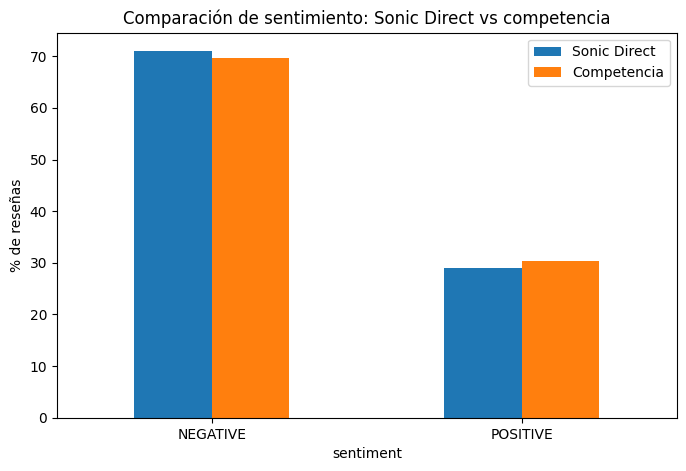

In [76]:
# Visualizamos la comparacion de forma mas intuitiva con un grafico de barras.
comparacion_sent.plot(kind="bar", figsize=(8, 5))
plt.title("Comparacion de sentimiento: Sonic Direct vs competencia")
plt.ylabel("% de rese?as")
plt.xticks(rotation=0)
plt.show()


## 8. Temas en la competencia

Ahora descubrimos los temas principales dentro de la competencia usando el mismo enfoque.
Esto nos ayuda a ver si los problemas y fortalezas del sector coinciden con los de la empresa objetivo.


In [77]:
# Generamos embeddings para las reviews de la competencia.
embeddings_competencia = model.encode(df_competencia["text"].tolist(), show_progress_bar=True)

# Creamos clusters tematicos para el conjunto de competidores.
kmeans_comp = KMeans(n_clusters=5, random_state=42)
df_competencia["topic"] = kmeans_comp.fit_predict(embeddings_competencia)


Batches: 100%|██████████| 172/172 [00:42<00:00,  4.08it/s]


In [78]:
# Revisamos ejemplos de topics de la empresa para etiquetarlos manualmente con mas criterio.
for i in range(5):
    print(f"
--- Topic empresa {i} ---")
    print(df_empresa[df_empresa["topic"] == i]["text"].head(5).to_string())



--- Topic empresa 0 ---
32164    well informed sales person resulted in our pur...
32168    great product excellent tv easy set up great p...
32190    tv very happy with the tv i have recently purc...
32197    the two men that delivered th the two men that...
32218    funny how the price on my sonyoled funny how t...

--- Topic empresa 1 ---
32163    our washing machine our washing machine broke ...
32182    i had problems but they were all resolved the ...
32183    good mistakes made but sorted staff friendly s...
32186    washer dryer delivery all good even despite th...
32187    chest freezer always willing to help good cust...

--- Topic empresa 2 ---
32165    excellent delivery crew delivery guys sangdeep...
32169    first time using this company wont be the last...
32173    excellent service absolutely fantastic service...
32177    always helpful friendly and always helpful fri...
32178    lovely guy who asked if i needed help lovely g...

--- Topic empresa 3 ---
32161    great 

In [79]:
# Hacemos lo mismo con la competencia para interpretar sus clusters.
for i in range(5):
    print(f"
--- Topic competencia {i} ---")
    print(df_competencia[df_competencia["topic"] == i]["text"].head(5).to_string())



--- Topic competencia 0 ---
29664    wanted a tv for an year old relative wanted a ...
29699    wiim ultra the box is slightly damager but doe...
29712    they took the piss bought a turn table and spe...
29715    puzzled by having three staff members puzzled ...
29724    dry poor customer care dry poor customer care ...

--- Topic competencia 1 ---
29672    jonathan in your bristol store was jonathan in...
29681    fantastic service goods arrived very quickly i...
29686    saw the tv online called in the shop it saw th...
29689    rude person serving me update i just had a cal...
29691    richer sounds let down by delivery service bou...

--- Topic competencia 2 ---
29687    there had been a price for a device on there h...
29701    poor website especially payment my main issue ...
29710    awful customer service when things go wrong or...
29713    great company to deal with the customer update...
29721    we havnt received any one to set the tv we hav...

--- Topic competencia 3 ---

## 9. Etiquetado manual de topics

Los clusters num?ricos todav?a no son muy interpretables por s? solos.
Por eso les asignamos nombres de negocio que resuman el tipo de conversaci?n dominante en cada grupo.


In [80]:
# Traducimos el numero de cluster a una etiqueta legible para negocio.
mapa_topics_empresa = {
    0: "Product and price",
    1: "Customer service and incidents",
    2: "Delivery",
    3: "Product quality",
    4: "Returns and refunds"
}

df_empresa["topic_name"] = df_empresa["topic"].map(mapa_topics_empresa)


In [81]:
# Creamos un mapeo equivalente para los clusters de la competencia.
mapa_topics_comp = {
    0: "Product and price",
    1: "Customer service",
    2: "Delivery",
    3: "Refunds and returns",
    4: "Product quality"
}

df_competencia["topic_name"] = df_competencia["topic"].map(mapa_topics_comp)


## 10. Sentimiento por topic

No solo importa el sentimiento global: tambi?n interesa saber en qu? temas aparecen m?s cr?ticas o m?s satisfacci?n.
Aqu? cruzamos topic y sentimiento para detectar puntos fuertes y puntos d?biles concretos.


In [82]:
# Calculamos la distribucion de sentimiento dentro de cada tema de la empresa.
sent_topic_empresa = (
    df_empresa.groupby(["topic_name", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

sent_topic_empresa_pct = sent_topic_empresa.div(sent_topic_empresa.sum(axis=1), axis=0) * 100
sent_topic_empresa_pct.round(2)


sentiment,NEGATIVE,POSITIVE
topic_name,,
Customer service and incidents,92.31,7.69
Delivery,55.56,44.44
Product and price,83.33,16.67
Product quality,50.00,50.00
Returns and refunds,58.82,41.18


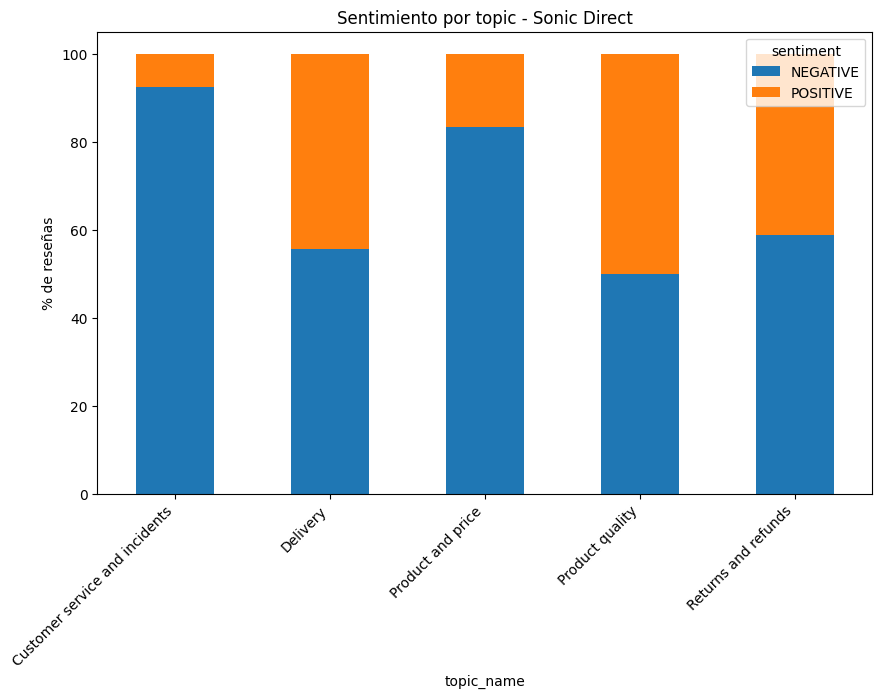

In [83]:
# Grafico apilado para ver de un vistazo que temas concentran mas opiniones negativas.
sent_topic_empresa_pct.plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Sentimiento por topic - Sonic Direct")
plt.ylabel("% de rese?as")
plt.xticks(rotation=45, ha="right")
plt.show()


In [84]:
# Repetimos el analisis por topic para la competencia.
sent_topic_comp = (
    df_competencia.groupby(["topic_name", "sentiment"])
    .size()
    .unstack(fill_value=0)
)

sent_topic_comp_pct = sent_topic_comp.div(sent_topic_comp.sum(axis=1), axis=0) * 100
sent_topic_comp_pct.round(2)


sentiment,NEGATIVE,POSITIVE
topic_name,,
Customer service,86.38,13.62
Delivery,81.78,18.22
Product and price,74.65,25.35
Product quality,74.74,25.26
Refunds and returns,37.53,62.47


## 11. Relacion entre sentimiento, topics y estrellas

Terminamos conectando el NLP con la valoraci?n num?rica en estrellas.
Esto ayuda a comprobar si los temas detectados y el sentimiento predicho tienen coherencia con la puntuaci?n que deja el cliente.


In [85]:
# Media de estrellas por sentimiento en la empresa.
df_empresa.groupby("sentiment")["stars"].mean()


sentiment
NEGATIVE    2.408451
POSITIVE    4.448276
Name: stars, dtype: float64

In [86]:
# Media de estrellas por sentimiento en la competencia.
df_competencia.groupby("sentiment")["stars"].mean()


sentiment
NEGATIVE    2.597960
POSITIVE    4.496712
Name: stars, dtype: float64

In [87]:
# Media de estrellas por topic en la empresa para detectar areas mejor y peor valoradas.
df_empresa.groupby("topic_name")["stars"].mean().sort_values()


topic_name
Customer service and incidents    2.333333
Delivery                          3.222222
Product quality                   3.300000
Product and price                 3.666667
Returns and refunds               3.705882
Name: stars, dtype: float64

In [88]:
# Media de estrellas por topic en la competencia.
df_competencia.groupby("topic_name")["stars"].mean().sort_values()


topic_name
Customer service       2.663813
Delivery               2.767426
Product quality        3.069588
Product and price      3.125134
Refunds and returns    4.106324
Name: stars, dtype: float64

## 12. Conclusiones

Con esta estructura ya puedes interpretar el proyecto en tres niveles:
- visi?n global de la reputaci?n de la empresa
- temas concretos que explican esa reputaci?n
- comparaci?n con el comportamiento medio de la competencia

Si quieres, el siguiente paso natural ser?a a?adir una celda final con conclusiones escritas y recomendaciones de negocio.
